# CLARA: Comprehension and Literacy Assessment for Readability Analysis

Welcome to the CLARA evaluation notebook! CLARA is a systematic platform designed to evaluate reading comprehension in smaller language models and perform detailed error analysis to diagnose why they fail.

This notebook leverages **Gemini Flash** (via API) to generate a fictitious reading passage and a set of multiple-choice questions split among three difficulty levels. We then run and compare models from the **GPT-2** family to observe how model scale impacts adherence to instructions, formatting stability, and overall comprehension accuracy. Results are persistently cached in Google Drive (or local workspace fallback).

### Cell 1: Environment Setup
**Description:**
This cell installs the required third-party libraries for the CLARA platform. These include `google-generativeai` (for accessing Gemini Flash), Hugging Face `transformers` and `accelerate` (for running GPT-2 models locally), and visualization libraries (`matplotlib`, `pandas`). Additionally, it attempts to mount Google Drive for persistent caching. If run outside of Google Colab, Google Drive mounting will gracefully fail or be skipped, and the platform will fall back to local caching.

In [17]:
import os
import sys

# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Google Colab: {IN_COLAB}")

# Install necessary libraries if in Colab or if they are missing
if IN_COLAB:
    print("Installing packages...")
    !pip install -q google-generativeai transformers accelerate pandas matplotlib torch
else:
    print("In local environment. Ensure you have installed: google-generativeai, transformers, pandas, matplotlib, torch, accelerate")

# Mount Google Drive if in Colab
if IN_COLAB:
    from google.colab import drive
    try:
        print("Mounting Google Drive...")
        drive.mount('/content/drive')
    except Exception as e:
        print("Could not mount Google Drive. Local caching will be used instead.")
        print(f"Error: {e}")

Running in Google Colab: True
Installing packages...
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Cell 2: Configuration & Parameters
**Description:**
This cell contains all the configurable parameters for the CLARA evaluation framework. You can specify your Gemini API key, select which Gemini model to use for story and question generation, choose which GPT-2 model sizes to run for the ablation study, configure the number of sampling trials per question (between 10 and 50), set the temperature, and define the caching directories.

In [18]:
import os

# --- Gemini Configuration ---
# When running in Google Colab, secrets are securely loaded using the Colab Secrets API.
GEMINI_API_KEY = None
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
except Exception:
    pass

if not GEMINI_API_KEY:
    GEMINI_API_KEY = os.environ.get("GOOGLE_API_KEY", "")

GEMINI_MODEL = "gemini-3.1-flash-lite"  # Fictitious or historical story and question generator

# --- Caching Options ---
USE_CACHE = False  # Toggle True to load from cache, False to discard cache and run fresh
SKIP_CACHE = not USE_CACHE  # Toggle True to bypass cache reading (forces regeneration of story and new evaluations)

# --- Story Content Options ---
# Choose from:
# 'fictional'      - Generates a completely novel, fictitious narrative.
# 'non-fictional'  - Generates a brief, true historical text to test models' parametric knowledge.
STORY_TYPE = "non-fictional"

# --- Question Difficulty Options ---
# If ENABLE_MEDIUM_HARD is True: 12 questions will be generated (3 for each level: Very Easy, Easy, Medium, Hard).
# If False: 10 questions will be generated (5 Very Easy, 5 Easy).
ENABLE_MEDIUM_HARD = True

# --- GPT-2 Ablation Configuration ---
# Choose from: 'gpt2' (small), 'gpt2-medium', 'gpt2-large', 'gpt2-xl'
# We will compare performance across these models.
# GPT2_MODELS_TO_EVALUATE = ["gpt2-medium"]
GPT2_MODELS_TO_EVALUATE = ["gpt2-large"]

# --- Gemma Family Ablation Configuration ---
# Choose from Gemma version 4 instruction-tuned models, e.g. 'google/gemma-4-E2B-it-assistant'
GEMMA_MODELS_TO_EVALUATE = ["gemma-4-26b-a4b-it"]
RUN = False  # Set Gemma evaluation to RUN=False by default

# --- Evaluation Parameters ---
RUN_COUNT = 5  # Number of generation trials per question (typically 10-50)
TEMPERATURE = 0.3  # Temperature for model answer sampling
MAX_NEW_TOKENS = 10  # Max tokens to generate to find the answer

# --- Caching Paths ---
# If Google Drive is mounted, we store the files there. Otherwise, we fallback to a local cache.
GOOGLE_DRIVE_DIR = "/content/drive/MyDrive/clara_cache/V2.0"
LOCAL_DIR = "./clara_cache"

print("Configurations loaded successfully.")
print(f"Gemini Model: {GEMINI_MODEL}")
print(f"Story Type: {STORY_TYPE}")
print(f"Use Cache: {USE_CACHE}")
print(f"Skip Cache: {SKIP_CACHE}")
print(f"GPT-2 Models for Ablation: {GPT2_MODELS_TO_EVALUATE}")
print(f"Gemma Models for Ablation: {GEMMA_MODELS_TO_EVALUATE}")
print(f"Runs per question: {RUN_COUNT}")
print(f"Enable Medium/Hard Questions: {ENABLE_MEDIUM_HARD}")


Configurations loaded successfully.
Gemini Model: gemini-3.1-flash-lite
Story Type: non-fictional
Use Cache: False
Skip Cache: True
GPT-2 Models for Ablation: ['gpt2-large']
Gemma Models for Ablation: ['gemma-4-26b-a4b-it']
Runs per question: 5
Enable Medium/Hard Questions: True


### Cell 3: Google Drive Caching Utilities
**Description:**
This cell implements robust caching utilities. These functions determine whether Google Drive is mounted and accessible. If so, caching is done in `/content/drive/MyDrive/clara_cache/`. If Google Drive is unavailable, the system automatically falls back to `./clara_cache/` in the local workspace. This preserves experiment outputs and prevents redundant API calls or heavy model inferences if the notebook is re-run.

In [19]:
import json
import os

def get_cache_directory():
    """Returns the mounted Google Drive cache path if available, else local path."""
    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs(GOOGLE_DRIVE_DIR, exist_ok=True)
        return GOOGLE_DRIVE_DIR
    else:
        os.makedirs(LOCAL_DIR, exist_ok=True)
        return LOCAL_DIR

def save_to_cache(filename, data):
    """Saves data (dict/list) as JSON to the active cache directory, both as latest and timestamped versions."""
    import datetime
    cache_dir = get_cache_directory()

    # Save as latest (overwriting existing latest-cache)
    filepath = os.path.join(cache_dir, filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Saved latest cache to: {filepath}")

    # Save as timestamped version
    base, ext = os.path.splitext(filename)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    timestamped_filename = f"{base}_{timestamp}{ext}"
    ts_filepath = os.path.join(cache_dir, timestamped_filename)
    with open(ts_filepath, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Saved timestamped cache to: {ts_filepath}")

def load_from_cache(filename):
    """Loads JSON data from the active cache directory if it exists and USE_CACHE is True and SKIP_CACHE is False, else returns None."""
    if not globals().get('USE_CACHE', True):
        print("Cache loading disabled (USE_CACHE = False). Ignoring cached files.")
        return None
    if globals().get('SKIP_CACHE', False):
        print("Cache bypass enabled (SKIP_CACHE = True). Skipping cached files loading.")
        return None
    cache_dir = get_cache_directory()
    filepath = os.path.join(cache_dir, filename)
    if os.path.exists(filepath):
        print(f"Loading cache from: {filepath}")
        with open(filepath, 'r', encoding='utf-8') as f:
            return json.load(f)
    return None

print(f"Active cache directory is: {get_cache_directory()}")


Active cache directory is: /content/drive/MyDrive/clara_cache/V2.0


### Cell 4: Gemini Story & Question Generator
**Description:**
This cell uses the Gemini API (via the `google-generativeai` SDK) to generate a unique, fictitious story and 10 easy or extra easy multiple-choice comprehension questions targeted at 1st grade students. To guarantee structured output, we supply a detailed prompt and ask for JSON output conforming to a specific schema. If a cached story exists in Drive or the local workspace, it loads it instead of calling the API.

In [20]:
import google.generativeai as genai
import json

# Setup the Gemini API key
if GEMINI_API_KEY:
    genai.configure(api_key=GEMINI_API_KEY)
else:
    # Attempt to load from environment variable or Colab Secrets
    try:
        from google.colab import userdata
        key = userdata.get('GEMINI_API_KEY')
        if key:
            genai.configure(api_key=key)
            GEMINI_API_KEY = key
            print("Loaded Gemini API key from Colab Secrets.")
    except Exception:
        print("WARNING: Gemini API Key is not set! Set GEMINI_API_KEY or configure Colab Secrets.")

# Cache filename is differentiated by the configured STORY_TYPE and ENABLE_MEDIUM_HARD
diff_suffix = "med_hard" if globals().get("ENABLE_MEDIUM_HARD", False) else "easy_only"
STORY_CACHE_FILE = f"story_questions_{STORY_TYPE}_{diff_suffix}.json"

def generate_story_and_questions():
    """Generates either a fictional story or true historical text and MC questions split by difficulty using Gemini."""
    enable_med_hard = globals().get("ENABLE_MEDIUM_HARD", False)

    if STORY_TYPE == "non-fictional":
        content_instruction = (
            "Generate a brief, true historical text (around 150-300 words) about a real historical event, "
            "written specifically for 1st grade students "
            "using very simple language, short sentences, and basic vocabulary."
        )
    else:
        content_instruction = (
            "Generate a completely fictitious, short story (around 150-300 words) written specifically for 1st grade students "
            "using very simple language, short sentences, and basic vocabulary."
        )

    if enable_med_hard:
        prompt = f"""
    {content_instruction}
    Based on this text, generate exactly 12 multiple-choice reading comprehension questions.
    The questions must cover four difficulty levels, with exactly three questions for each level:
    1. "Very Easy": the correct answer is easy to find. Wrong choices are almost illogical.
    2. "Easy": also a recall question, but the correct choice is not as easy to find.
    3. "Medium": requires inference, or logic.
    4. "Hard": those are multi-hop questions.

    For each question, provide 4 options (A, B, C, D) and specify the single correct_answer ("A", "B", "C", or "D").
    Also provide a brief explanation of why that answer is correct.

    Your output MUST be a valid JSON object matching this schema:
    {{
      "story": "The text of the story/historical passage here...",
      "questions": [
        {{
          "id": 1,
          "difficulty": "Very Easy",
          "question": "The text of the question?",
          "options": {{
            "A": "Option A text",
            "B": "Option B text",
            "C": "Option C text",
            "D": "Option D text"
          }},
          "correct_answer": "A",
          "explanation": "Brief explanation..."
        }},
        ...
      ]
    }}
    Ensure the JSON is well-formed, valid, and contains exactly 12 questions (3 for each of Very Easy, Easy, Medium, Hard). Do not wrap the JSON in markdown code blocks like ```json ... ```. Just return raw JSON.
    """
    else:
        prompt = f"""
    {content_instruction}
    Based on this text, generate exactly 10 multiple-choice reading comprehension questions.
    The questions must cover two difficulty levels, with exactly five questions for each level:
    1. "Very Easy": the correct answer is easy to find. Wrong choices are almost illogical.
    2. "Easy": also a recall question, but the correct choice is not as easy to find.

    For each question, provide 4 options (A, B, C, D) and specify the single correct_answer ("A", "B", "C", or "D").
    Also provide a brief explanation of why that answer is correct.

    Your output MUST be a valid JSON object matching this schema:
    {{
      "story": "The text of the story/historical passage here...",
      "questions": [
        {{
          "id": 1,
          "difficulty": "Very Easy",
          "question": "The text of the question?",
          "options": {{
            "A": "Option A text",
            "B": "Option B text",
            "C": "Option C text",
            "D": "Option D text"
          }},
          "correct_answer": "A",
          "explanation": "Brief explanation..."
        }},
        ...
      ]
    }}
    Ensure the JSON is well-formed, valid, and contains exactly 10 questions (5 of Very Easy difficulty, 5 of Easy difficulty). Do not wrap the JSON in markdown code blocks like ```json ... ```. Just return raw JSON.
    """

    print(f"Calling Gemini ({GEMINI_MODEL}) to generate {STORY_TYPE} story and questions...")

    # Configure generation to request JSON output
    model = genai.GenerativeModel(GEMINI_MODEL)
    response = model.generate_content(
        prompt,
        generation_config={"response_mime_type": "application/json", "temperature": 2.0}
    )

    content = response.text.strip()
    # Parse and validate JSON
    data = json.loads(content)
    return data

fictional_dummy = {
    "story": "A Little Bird. Max is a little blue bird. He lives in a tall green tree. Max likes to sing in the morning. He sings a happy song. One day, Max saw a red apple on the ground. The apple was sweet and juicy. Max ate the apple and flew back to his nest. He felt very happy and went to sleep.",
    "questions": [
        {
            "id": 1,
            "difficulty": "Very Easy",
            "question": "What color is Max?",
            "options": {
                "A": "Red",
                "B": "Blue",
                "C": "Green",
                "D": "Yellow"
            },
            "correct_answer": "B",
            "explanation": "The story says Max is a little blue bird."
        },
        {
            "id": 2,
            "difficulty": "Very Easy",
            "question": "What is Max?",
            "options": {
                "A": "A dog",
                "B": "A cat",
                "C": "A bird",
                "D": "A fish"
            },
            "correct_answer": "C",
            "explanation": "The story says Max is a little blue bird."
        },
        {
            "id": 3,
            "difficulty": "Very Easy",
            "question": "Where does Max live?",
            "options": {
                "A": "In a house",
                "B": "In a tall green tree",
                "C": "In a lake",
                "D": "In a barn"
            },
            "correct_answer": "B",
            "explanation": "The story states that he lives in a tall green tree."
        },
        {
            "id": 4,
            "difficulty": "Very Easy",
            "question": "When does Max like to sing?",
            "options": {
                "A": "At night",
                "B": "In the morning",
                "C": "In the afternoon",
                "D": "Never"
            },
            "correct_answer": "B",
            "explanation": "The story says Max likes to sing in the morning."
        },
        {
            "id": 5,
            "difficulty": "Very Easy",
            "question": "What kind of song does Max sing?",
            "options": {
                "A": "A sad song",
                "B": "A loud song",
                "C": "A happy song",
                "D": "A quiet song"
            },
            "correct_answer": "C",
            "explanation": "The story says he sings a happy song."
        },
        {
            "id": 6,
            "difficulty": "Easy",
            "question": "What did Max see on the ground?",
            "options": {
                "A": "A red apple",
                "B": "A small worm",
                "C": "A blue toy",
                "D": "A green leaf"
            },
            "correct_answer": "A",
            "explanation": "The story says Max saw a red apple on the ground."
        },
        {
            "id": 7,
            "difficulty": "Easy",
            "question": "What color was the apple?",
            "options": {
                "A": "Green",
                "B": "Yellow",
                "C": "Blue",
                "D": "Red"
            },
            "correct_answer": "D",
            "explanation": "The story states that he saw a red apple."
        },
        {
            "id": 8,
            "difficulty": "Easy",
            "question": "How did the apple taste?",
            "options": {
                "A": "Sour",
                "B": "Sweet and juicy",
                "C": "Salty",
                "D": "Bad"
            },
            "correct_answer": "B",
            "explanation": "The story says the apple was sweet and juicy."
        },
        {
            "id": 9,
            "difficulty": "Easy",
            "question": "Where did Max fly after eating the apple?",
            "options": {
                "A": "To the lake",
                "B": "To the ground",
                "C": "Back to his nest",
                "D": "To a house"
            },
            "correct_answer": "C",
            "explanation": "The story says Max ate the apple and flew back to his nest."
        },
        {
            "id": 10,
            "difficulty": "Easy",
            "question": "What did Max do in his nest?",
            "options": {
                "A": "He sang",
                "B": "He played",
                "C": "He went to sleep",
                "D": "He went to sleep"
            },
            "correct_answer": "C",
            "explanation": "The story states that he went to sleep."
        }
    ]
}

fictional_dummy_med_hard = {
    "story": "A Little Bird. Max is a little blue bird. He lives in a tall green tree. Max likes to sing in the morning. He sings a happy song. One day, Max saw a red apple on the ground. The apple was sweet and juicy. Max ate the apple and flew back to his nest. He felt very happy and went to sleep.",
    "questions": [
        {
            "id": 1,
            "difficulty": "Very Easy",
            "question": "What color is Max?",
            "options": {
                "A": "Red",
                "B": "Blue",
                "C": "Green",
                "D": "Yellow"
            },
            "correct_answer": "B",
            "explanation": "The story says Max is a little blue bird."
        },
        {
            "id": 2,
            "difficulty": "Very Easy",
            "question": "What is Max?",
            "options": {
                "A": "A dog",
                "B": "A cat",
                "C": "A bird",
                "D": "A fish"
            },
            "correct_answer": "C",
            "explanation": "The story says Max is a little blue bird."
        },
        {
            "id": 3,
            "difficulty": "Very Easy",
            "question": "Where does Max live?",
            "options": {
                "A": "In a house",
                "B": "In a tall green tree",
                "C": "In a lake",
                "D": "In a barn"
            },
            "correct_answer": "B",
            "explanation": "The story states that he lives in a tall green tree."
        },
        {
            "id": 4,
            "difficulty": "Easy",
            "question": "When does Max like to sing?",
            "options": {
                "A": "At night",
                "B": "In the morning",
                "C": "In the afternoon",
                "D": "Never"
            },
            "correct_answer": "B",
            "explanation": "The story says Max likes to sing in the morning."
        },
        {
            "id": 5,
            "difficulty": "Easy",
            "question": "What did Max see on the ground?",
            "options": {
                "A": "A red apple",
                "B": "A small worm",
                "C": "A blue toy",
                "D": "A green leaf"
            },
            "correct_answer": "A",
            "explanation": "The story says Max saw a red apple on the ground."
        },
        {
            "id": 6,
            "difficulty": "Easy",
            "question": "How did the apple taste?",
            "options": {
                "A": "Sour",
                "B": "Sweet and juicy",
                "C": "Salty",
                "D": "Bad"
            },
            "correct_answer": "B",
            "explanation": "The story says the apple was sweet and juicy."
        },
        {
            "id": 7,
            "difficulty": "Medium",
            "question": "Why did Max fly back to his nest?",
            "options": {
                "A": "Because it started to rain heavily",
                "B": "Because he wanted to find a red apple",
                "C": "Because he finished eating the apple and wanted to rest",
                "D": "Because he heard another bird singing"
            },
            "correct_answer": "C",
            "explanation": "The story states Max ate the apple and flew back to his nest to go to sleep, which implies he wanted to rest."
        },
        {
            "id": 8,
            "difficulty": "Medium",
            "question": "If Max woke up in the afternoon, when would he most likely sing next?",
            "options": {
                "A": "The next morning",
                "B": "Right away in the afternoon",
                "C": "At dinner time",
                "D": "At midnight"
            },
            "correct_answer": "A",
            "explanation": "The story mentions that Max likes to sing in the morning."
        },
        {
            "id": 9,
            "difficulty": "Medium",
            "question": "Which of the following is a fact about Max from the story?",
            "options": {
                "A": "He flew to the lake to drink water",
                "B": "He hates red apples",
                "C": "He lives in a house",
                "D": "He ate a sweet and juicy red apple"
            },
            "correct_answer": "D",
            "explanation": "The story explicitly says Max saw and ate a sweet and juicy red apple."
        },
        {
            "id": 10,
            "difficulty": "Hard",
            "question": "Based on the order of events in the story, what did Max do right after eating the red apple?",
            "options": {
                "A": "He sang a happy song",
                "B": "He searched for a green leaf",
                "C": "He flew back to his nest",
                "D": "He went to sleep immediately on the ground"
            },
            "correct_answer": "C",
            "explanation": "The story states: 'Max ate the apple and flew back to his nest. He felt very happy and went to sleep.'"
        },
        {
            "id": 11,
            "difficulty": "Hard",
            "question": "Which of the following describes the sequence of Max's emotions or actions from morning to sleeping?",
            "options": {
                "A": "Sang a happy song, saw and ate a sweet apple, flew to his nest, fell asleep",
                "B": "Fell asleep, ate a sour apple, sang a sad song, flew to a tall green tree",
                "C": "Sang a loud song, saw a small worm, flew back to his nest, felt very sad",
                "D": "Flew back to his nest, saw a red apple, sang a happy song, fell asleep"
            },
            "correct_answer": "A",
            "explanation": "This option correctly orders Max's morning singing, eating the apple, flying to his nest, and falling asleep."
        },
        {
            "id": 12,
            "difficulty": "Hard",
            "question": "If a cat was sitting on the ground near the apple, why would Max's decision to eat the apple and fly back to his nest be considered lucky?",
            "options": {
                "A": "Because the cat was a vegetarian and wanted the apple instead of the bird",
                "B": "Because Max was safe on the ground while eating and returned safely to his tree",
                "C": "Because the cat fell asleep on the apple",
                "D": "Because the cat helped Max fly back to his tree"
            },
            "correct_answer": "B",
            "explanation": "Max eating on the ground where a cat is sitting is dangerous, so returning safely to his tree unharmed is lucky."
        }
    ]
}

non_fictional_dummy = {
    "story": "The First Moon Walk. Long ago, in 1969, three brave men went to space. Their ship was called Apollo 11. Neil Armstrong was one of the men. They flew to the moon in a rocket. Neil Armstrong was the very first person to walk on the moon. He stepped onto the dusty gray ground. He said it was a giant leap for all people. The world watched on television and cheered.",
    "questions": [
        {
            "id": 1,
            "difficulty": "Very Easy",
            "question": "In what year did the men go to space?",
            "options": {
                "A": "1969",
                "B": "1999",
                "C": "2020",
                "D": "1950"
            },
            "correct_answer": "A",
            "explanation": "The story explicitly states that the men went to space in 1969."
        },
        {
            "id": 2,
            "difficulty": "Very Easy",
            "question": "How many brave men went to space?",
            "options": {
                "A": "Two",
                "B": "Three",
                "C": "Four",
                "D": "Five"
            },
            "correct_answer": "B",
            "explanation": "The story says three brave men went to space."
        },
        {
            "id": 3,
            "difficulty": "Very Easy",
            "question": "What was their ship called?",
            "options": {
                "A": "Eagle",
                "B": "Apollo 11",
                "C": "Starship",
                "D": "Saturn"
            },
            "correct_answer": "B",
            "explanation": "The story says their ship was called Apollo 11."
        },
        {
            "id": 4,
            "difficulty": "Very Easy",
            "question": "Who was the first person to walk on the moon?",
            "options": {
                "A": "Buzz Aldrin",
                "B": "Neil Armstrong",
                "C": "Michael Collins",
                "D": "John F. Kennedy"
            },
            "correct_answer": "B",
            "explanation": "The story explicitly says Neil Armstrong was the very first person to walk on the moon."
        },
        {
            "id": 5,
            "difficulty": "Very Easy",
            "question": "Where did they fly in a rocket?",
            "options": {
                "A": "To the sun",
                "B": "To the moon",
                "C": "To Mars",
                "D": "To a star"
            },
            "correct_answer": "B",
            "explanation": "The story states they flew to the moon in a rocket."
        },
        {
            "id": 6,
            "difficulty": "Easy",
            "question": "What was the color of the ground on the moon?",
            "options": {
                "A": "Red",
                "B": "Blue",
                "C": "Dusty gray",
                "D": "Bright green"
            },
            "correct_answer": "C",
            "explanation": "The story says Neil Armstrong stepped onto the dusty gray ground."
        },
        {
            "id": 7,
            "difficulty": "Easy",
            "question": "What did Neil Armstrong do on the moon?",
            "options": {
                "A": "He slept",
                "B": "He walked on it",
                "C": "He painted it",
                "D": "He ran"
            },
            "correct_answer": "B",
            "explanation": "The story says Neil Armstrong walked on the moon."
        },
        {
            "id": 8,
            "difficulty": "Easy",
            "question": "How did the world watch the moon walk?",
            "options": {
                "A": "On television",
                "B": "In a book",
                "C": "On a phone",
                "D": "In the sky"
            },
            "correct_answer": "A",
            "explanation": "The story says the world watched on television."
        },
        {
            "id": 9,
            "difficulty": "Easy",
            "question": "What did the world do when they watched?",
            "options": {
                "A": "They cried",
                "B": "They cheered",
                "C": "They went to sleep",
                "D": "They ran away"
            },
            "correct_answer": "B",
            "explanation": "The story says the world watched on television and cheered."
        },
        {
            "id": 10,
            "difficulty": "Easy",
            "question": "What kind of leap did Neil say it was?",
            "options": {
                "A": "A tiny hop",
                "B": "A giant leap",
                "C": "A scary jump",
                "D": "A fast run"
            },
            "correct_answer": "B",
            "explanation": "The story says Neil Armstrong said it was a giant leap for all people."
        }
    ]
}

non_fictional_dummy_med_hard = {
    "story": "The First Moon Walk. Long ago, in 1969, three brave men went to space. Their ship was called Apollo 11. Neil Armstrong was one of the men. They flew to the moon in a rocket. Neil Armstrong was the very first person to walk on the moon. He stepped onto the dusty gray ground. He said it was a giant leap for all people. The world watched on television and cheered.",
    "questions": [
        {
            "id": 1,
            "difficulty": "Very Easy",
            "question": "In what year did the men go to space?",
            "options": {
                "A": "1969",
                "B": "1999",
                "C": "2020",
                "D": "1950"
            },
            "correct_answer": "A",
            "explanation": "The story explicitly states that the men went to space in 1969."
        },
        {
            "id": 2,
            "difficulty": "Very Easy",
            "question": "How many brave men went to space?",
            "options": {
                "A": "Two",
                "B": "Three",
                "C": "Four",
                "D": "Five"
            },
            "correct_answer": "B",
            "explanation": "The story says three brave men went to space."
        },
        {
            "id": 3,
            "difficulty": "Very Easy",
            "question": "What was their ship called?",
            "options": {
                "A": "Eagle",
                "B": "Apollo 11",
                "C": "Starship",
                "D": "Saturn"
            },
            "correct_answer": "B",
            "explanation": "The story says their ship was called Apollo 11."
        },
        {
            "id": 4,
            "difficulty": "Easy",
            "question": "Who was the first person to walk on the moon?",
            "options": {
                "A": "Buzz Aldrin",
                "B": "Neil Armstrong",
                "C": "Michael Collins",
                "D": "John F. Kennedy"
            },
            "correct_answer": "B",
            "explanation": "The story explicitly says Neil Armstrong was the very first person to walk on the moon."
        },
        {
            "id": 5,
            "difficulty": "Easy",
            "question": "Where did they fly in a rocket?",
            "options": {
                "A": "To the sun",
                "B": "To the moon",
                "C": "To Mars",
                "D": "To a star"
            },
            "correct_answer": "B",
            "explanation": "The story states they flew to the moon in a rocket."
        },
        {
            "id": 6,
            "difficulty": "Easy",
            "question": "What was the color of the ground on the moon?",
            "options": {
                "A": "Red",
                "B": "Blue",
                "C": "Dusty gray",
                "D": "Bright green"
            },
            "correct_answer": "C",
            "explanation": "The story says Neil Armstrong stepped onto the dusty gray ground."
        },
        {
            "id": 7,
            "difficulty": "Medium",
            "question": "Why did the world cheer while watching the event?",
            "options": {
                "A": "Because they were scared of space rockets",
                "B": "Because they wanted to sleep",
                "C": "Because walking on the moon was an amazing, historic achievement for people",
                "D": "Because Neil Armstrong made a painting of the moon"
            },
            "correct_answer": "C",
            "explanation": "The story says the world watched on television and cheered, representing universal excitement for this historic leap."
        },
        {
            "id": 8,
            "difficulty": "Medium",
            "question": "Based on the story, why can Neil Armstrong be described as brave?",
            "options": {
                "A": "Because he flew in a rocket to space and walked on the moon",
                "B": "Because he was the oldest person in space",
                "C": "Because he could run very fast",
                "D": "Because he did not watch television"
            },
            "correct_answer": "A",
            "explanation": "The text calls the astronauts 'brave men' who went to space and walked on the moon, indicating their bravery."
        },
        {
            "id": 9,
            "difficulty": "Medium",
            "question": "What does the phrase 'giant leap for all people' imply about the moon landing?",
            "options": {
                "A": "It was a tiny jump on the ground",
                "B": "It was only helpful for Neil Armstrong",
                "C": "It was a scary leap that nobody liked",
                "D": "It was a very big progress or milestone for humanity"
            },
            "correct_answer": "D",
            "explanation": "Calling it a giant leap 'for all people' indicates that this achievement is a huge step forward for the entire human race."
        },
        {
            "id": 10,
            "difficulty": "Hard",
            "question": "Which of the following sequence of events is correct according to the story?",
            "options": {
                "A": "Neil Armstrong walked on the moon before the rocket was built",
                "B": "The crew flew in a rocket, Neil walked on the dusty gray ground, and the world watched and cheered",
                "C": "The world watched television, then the men flew in Apollo 11, then they became brave",
                "D": "The men flew to Mars, then Apollo 11 returned, and then it was 1969"
            },
            "correct_answer": "B",
            "explanation": "This sequence correctly reflects the chronological order: flying to the moon, stepping on the moon, and the world watching/cheering."
        },
        {
            "id": 11,
            "difficulty": "Hard",
            "question": "Who of the following traveled in the ship Apollo 11 in 1969?",
            "options": {
                "A": "Neil Armstrong and two other brave men",
                "B": "Neil Armstrong and television reporters",
                "C": "Buzz Aldrin alone",
                "D": "A group of five space tourists"
            },
            "correct_answer": "A",
            "explanation": "The story mentions that in 1969, three brave men went to space in Apollo 11, and Neil Armstrong was one of those three men."
        },
        {
            "id": 12,
            "difficulty": "Hard",
            "question": "If television was not invented in 1969, how would the world's reaction described in the story have changed?",
            "options": {
                "A": "The brave men would not have flown to space",
                "B": "Neil Armstrong would have walked on Mars instead",
                "C": "The world would not have watched Neil Armstrong walk on the moon in real-time on TV",
                "D": "They would have cheered louder because of radios"
            },
            "correct_answer": "C",
            "explanation": "The story says: 'The world watched on television and cheered'. Without TV, they could not have watched the live television broadcast."
        }
    ]
}

# Main execution for Cell 8: Load from cache or generate
cached_data = load_from_cache(STORY_CACHE_FILE)
if cached_data:
    story_data = cached_data
    print(f"Successfully loaded {STORY_TYPE} story and questions from cache.")
else:
    try:
        if GEMINI_API_KEY:
            story_data = generate_story_and_questions()
            save_to_cache(STORY_CACHE_FILE, story_data)
            print(f"Successfully generated and cached {STORY_TYPE} story and questions.")
        else:
            raise ValueError("No API Key provided, falling back to dummy dataset.")
    except Exception as e:
        print(f"Error generating story: {e}")
        print(f"Creating a fallback/dummy {STORY_TYPE} story dataset for demonstration.")
        is_med_hard = globals().get("ENABLE_MEDIUM_HARD", False)
        if STORY_TYPE == "non-fictional":
            story_data = non_fictional_dummy_med_hard if is_med_hard else non_fictional_dummy
        else:
            story_data = fictional_dummy_med_hard if is_med_hard else fictional_dummy
        save_to_cache(STORY_CACHE_FILE, story_data)

# Print a preview of the story and a question
print("\n--- STORY PREVIEW ---")
print(story_data["story"][:300] + "...")
print(f"Total Questions Generated: {len(story_data['questions'])}")



Cache loading disabled (USE_CACHE = False). Ignoring cached files.
Calling Gemini (gemini-3.1-flash-lite) to generate non-fictional story and questions...
Saved latest cache to: /content/drive/MyDrive/clara_cache/V2.0/story_questions_non-fictional_med_hard.json
Saved timestamped cache to: /content/drive/MyDrive/clara_cache/V2.0/story_questions_non-fictional_med_hard_20260726_034409.json
Successfully generated and cached non-fictional story and questions.

--- STORY PREVIEW ---
Long ago, a man named George Washington became the first leader of the United States. He was a brave soldier. He led his army during a war. People liked him because he was honest and kind. When the war was over, he wanted to go home. But his country needed a president. So, he became the first presid...
Total Questions Generated: 12


### Cell 5: GPT-2 Evaluator
**Description:**
This cell contains the evaluation engine for GPT-2 models. It downloads model weights from HuggingFace, constructs structured prompts matching the model's capabilities, runs multiple sampling trials (10 to 50 times per question) using temperature-controlled generation, and parses the outputs. GPT-2 models can be highly verbose or repetitive, so we implement robust parsing and validation. Any answer that cannot be resolved to a clean multiple-choice letter ("A", "B", "C", or "D") is discarded.

In [25]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import re

def clean_and_parse_answer(new_text):
    """
    Parses the generated response from model generations.
    It expects the model to output something containing '<Option Letter>A</Option Letter>' or just 'A'.
    """
    new_text = new_text.strip()
    print(f"Parsing: {new_text}")

    # Check for direct answer patterns, including XML-style <Option Letter> tags
    patterns = [
        r"<Option Letter>\s*([A-D])\s*</Option Letter>",
        r"(?:Answer|Option|Correct):\s*<Option Letter>\s*([A-D])\s*</Option Letter>",
        r"([A-D])\s*</Option Letter>",
        r"(?:Answer|Option|Correct):\s*([A-D])",
        r"^\s*([A-D])\b",
        r"\[([A-D])\]",
        r"\b([A-D])\b"
    ]

    for pattern in patterns:
        match = re.search(pattern, new_text, re.IGNORECASE)
        if match:
            parsed_letter = match.group(1).upper()
            return parsed_letter

    return None  # Discard if it doesn't meet the format

def evaluate_single_model(model_name, story_data, runs=20, temp=0.7):
    """
    Downloads model weights, runs evaluation, and returns raw results.
    We run 'runs' trials per question to record token choice distribution/stochastic behavior.
    """
    print(f"Loading weights for model: {model_name} ...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)

    # Set padding token to eos token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    print(f"Model loaded onto {device}.")

    story_text = story_data["story"]
    results = []

    # Get the first question as a one-shot example
    first_q = story_data["questions"][0]
    ex_options_str = "\n".join([f"{k}: {v}" for k, v in first_q["options"].items()])
    one_shot_example = (
        f"Example:\n"
        f"Question: {first_q['question']}\n"
        f"Options:\n{ex_options_str}\n"
        f"Answer: <Selected Answer>{first_q['correct_answer']}</Selected Answer>\n\n"
    )

    for q in story_data["questions"]:
        q_id = q["id"]
        difficulty = q["difficulty"]
        question_text = q["question"]
        options = q["options"]
        correct_answer = q["correct_answer"]
        explanation = q.get("explanation", "")

        # Build options text
        options_str = "\n".join([f"{k}: {v}" for k, v in options.items()])

        # Structure the prompt with strict formatting guidelines using a one-shot example and <Option Letter> tags
        prompt = (
            f"Instruction: Please read the Story and answer the question."

            f"\n{story_text}\n\n"
            # f"{one_shot_example}"
            f"{question_text}\n"
            # f"Options:\n{options_str}\n\n"
            f""
        )

        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        valid_trials = 0
        total_trials = 0
        correct_count = 0
        trial_answers = []

        print("")
        print(f"--- Evaluating Question {q_id} ({difficulty}) ---")
        print(f"Correct answer: {correct_answer}.")
        print(f"Question: {question_text}.")
        print(f"Answers: {options_str}")
        print("")

        # Loop-based allows clean logging of random samples
        for trial in range(runs):
            total_trials += 1
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=True,
                    temperature=temp,
                    pad_token_id=tokenizer.eos_token_id
                )

            # Extract and decode only the newly generated tokens
            input_len = inputs["input_ids"].shape[1]
            new_tokens = outputs[0][input_len:]
            new_text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
            parsed = clean_and_parse_answer(new_text)

            if parsed:
                valid_trials += 1
                is_correct = (parsed == correct_answer)
                if is_correct:
                    correct_count += 1
                trial_answers.append({
                    "trial": trial,
                    "raw_output": new_text,
                    "parsed_answer": parsed,
                    "is_correct": is_correct
                })
            else:
                trial_answers.append({
                    "trial": trial,
                    "raw_output": new_text,
                    "parsed_answer": None,
                    "is_correct": False
                })

        results.append({
            "question_id": q_id,
            "difficulty": difficulty,
            "question": question_text,
            "correct_answer": correct_answer,
            "total_trials": total_trials,
            "valid_trials": valid_trials,
            "correct_trials": correct_count,
            "accuracy": (correct_count / valid_trials) if valid_trials > 0 else 0.0,
            "trials_detail": trial_answers
        })

    return results

print("Evaluation engine ready.")


Evaluation engine ready.


### Cell 6: Ablation Study Runner
**Description:**
This cell executes the ablation study across the specified GPT-2 models. It checks if the cache file for each model exists in Drive or local storage. If yes, it loads the cached result; otherwise, it triggers the evaluation, processes the results, and caches them immediately to avoid data loss.

In [26]:
ablation_results = {}

for model_name in GPT2_MODELS_TO_EVALUATE:
    # Use clean file naming (replace slashes with underscores)
    safe_model_name = model_name.replace("/", "_")
    diff_suffix = "med_hard" if globals().get("ENABLE_MEDIUM_HARD", False) else "easy_only"
    cache_file = f"gpt2_results_{safe_model_name}_{RUN_COUNT}_{diff_suffix}.json"

    cached_res = load_from_cache(cache_file)
    if cached_res:
        print(f"Loaded evaluation results for {model_name} from cache.")
        ablation_results[model_name] = cached_res
    else:
        print(f"\n--- Evaluating Model: {model_name} ---")
        try:
            results = evaluate_single_model(model_name, story_data, runs=RUN_COUNT, temp=TEMPERATURE)
            save_to_cache(cache_file, results)
            ablation_results[model_name] = results
        except Exception as e:
            print(f"Error evaluating model {model_name}: {e}")

print("\nAll model evaluations completed/loaded.")

Cache loading disabled (USE_CACHE = False). Ignoring cached files.

--- Evaluating Model: gpt2-large ---
Loading weights for model: gpt2-large ...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

Model loaded onto cpu.

--- Evaluating Question 1 (Very Easy) ---
Correct answer: A.
Question: Who was the first president of the United States?.
Answers: A: George Washington
B: A space man
C: A dragon
D: A talking cat

Parsing: Answer: George Washington

Story:
Parsing: Answer: George Washington

What is the
Parsing: Answer: George Washington

The story of
Parsing: Answer: George Washington.

How many
Parsing: Answer: George Washington

Long ago,

--- Evaluating Question 2 (Very Easy) ---
Correct answer: C.
Question: What was George Washington before he was president?.
Answers: A: A teacher
B: A baker
C: A soldier
D: A cook

Parsing: George Washington was born in 1753. He
Parsing: He was a farmer. He was a good
Parsing: George Washington was a man who was born in
Parsing: George Washington was born in 1753. He
Parsing: George Washington was a farmer. He was a

--- Evaluating Question 3 (Very Easy) ---
Correct answer: B.
Question: Where did George Washington go when he stopped being p

### Cell 6b: Gemini-based Batch Parser
**Description:**
This cell implements a Gemini-based Batch Parser that processes the GPT-2 trial raw outputs in batch for each question, mapping them to the closest choice (A, B, C, D) using the same Gemini Flash model. If no choice matches or if no answer was provided, it returns 'undefined'. A rule-based fallback handles missing keys or API failures gracefully.


In [27]:
import google.generativeai as genai
import json
import time

def parse_batch_with_gemini(question_text, options, trials):
    """
    Calls Gemini Flash to parse a batch of raw completions for a given question.
    """
    if not globals().get('GEMINI_API_KEY', None):
        raise ValueError("GEMINI_API_KEY is not set.")

    # Build options text
    options_str = "\n".join([f"{k}: {v}" for k, v in options.items()])

    # Format trials for Gemini prompt
    trials_input = []
    for t in trials:
        trials_input.append({
            "trial_id": t["trial"],
            "raw_output": t["raw_output"]
        })

    prompt = f"""
    You are an expert answer parser for a reading comprehension evaluation task.
    You are given a multiple-choice question, its choices (A, B, C, D), and a list of raw text completions generated by a language model attempting to answer the question.

    For each trial, your task is to identify the choice (A, B, C, or D) that is closest in meaning or content to what the language model answered in its raw output.
    - If the raw output contains a clear statement of one of the choices or indicates it (even with some extra text or minor typos), map it to that option letter ("A", "B", "C", or "D").
    - If the raw output is empty, completely irrelevant, contains no answer at all, or says things like 'Answer: ' without any option, or does not match any of the options, map it to "undefined".

    Question: {question_text}

    Options:
    {options_str}

    Raw Outputs to Parse (JSON format):
    {json.dumps(trials_input, indent=2)}

    Your output MUST be a valid JSON array of objects, where each object has "trial_id" and "mapped_choice".
    "mapped_choice" must be exactly one of "A", "B", "C", "D", or "undefined".
    Do not include any explanation or markdown formatting like ```json ... ```. Just return raw JSON.

    Example output format:
    [
      {{"trial_id": 0, "mapped_choice": "A"}},
      {{"trial_id": 1, "mapped_choice": "undefined"}}
    ]
    """

    model = genai.GenerativeModel(GEMINI_MODEL)
    response = model.generate_content(
        prompt,
        generation_config={"response_mime_type": "application/json", "temperature": 0.0}
    )

    content = response.text.strip()
    parsed_json = json.loads(content)
    return parsed_json

# Run Gemini Batch Parser and update ablation_results
parsed_ablation_results = {}

for model_name, results in ablation_results.items():
    safe_model_name = model_name.replace("/", "_")
    diff_suffix = "med_hard" if globals().get("ENABLE_MEDIUM_HARD", False) else "easy_only"
    parsed_cache_file = f"gpt2_parsed_results_{safe_model_name}_{RUN_COUNT}_{diff_suffix}.json"

    cached_res = load_from_cache(parsed_cache_file)
    if cached_res:
        print(f"Loaded parsed results for {model_name} from cache.")
        parsed_ablation_results[model_name] = cached_res
    else:
        print(f"\n--- Running Gemini Parser for {model_name} ---")
        parsed_results = []
        for q_res in results:
            q_id = q_res["question_id"]
            difficulty = q_res["difficulty"]
            question_text = q_res["question"]
            correct_answer = q_res["correct_answer"]

            # Find options for this question from story_data
            q_orig = next(q for q in story_data["questions"] if q["id"] == q_id)
            options = q_orig["options"]

            trials = q_res["trials_detail"]
            print(f"Parsing {len(trials)} trials for Q{q_id} ({difficulty})...")

            # Standardize difficulty naming
            if difficulty == "Extra Easy":
                difficulty = "Very Easy"

            choice_map = {}
            try:
                mapped_trials = parse_batch_with_gemini(question_text, options, trials)
                # Create a map from trial_id to mapped_choice
                choice_map = {item["trial_id"]: item["mapped_choice"] for item in mapped_trials}
                time.sleep(1) # Simple rate limit buffer
            except Exception as e:
                print(f"Error parsing with Gemini for Q{q_id}: {e}. Falling back to rule-based parsing.")
                for t in trials:
                    # Use clean_and_parse_answer on the raw output
                    reg_parsed = clean_and_parse_answer(t["raw_output"])
                    if reg_parsed is None:
                        choice_map[t["trial"]] = "undefined"
                    else:
                        choice_map[t["trial"]] = reg_parsed

            updated_trials = []
            correct_count = 0
            undefined_count = 0
            valid_count = 0

            for t in trials:
                t_id = t["trial"]
                mapped_choice = choice_map.get(t_id, "undefined")

                # Check if mapped choice is valid
                if mapped_choice not in ["A", "B", "C", "D"]:
                    mapped_choice = "undefined"

                if mapped_choice == "undefined":
                    undefined_count += 1
                else:
                    valid_count += 1

                is_correct = (mapped_choice == correct_answer)
                if is_correct:
                    correct_count += 1

                updated_trials.append({
                    "trial": t_id,
                    "raw_output": t["raw_output"],
                    "parsed_answer": mapped_choice,
                    "is_correct": is_correct
                })

            parsed_results.append({
                "question_id": q_id,
                "difficulty": difficulty,
                "question": question_text,
                "correct_answer": correct_answer,
                "total_trials": len(trials),
                "valid_trials": valid_count,
                "undefined_count": undefined_count,
                "correct_trials": correct_count,
                "accuracy": (correct_count / len(trials)) if len(trials) > 0 else 0.0,
                "trials_detail": updated_trials
            })

        save_to_cache(parsed_cache_file, parsed_results)
        parsed_ablation_results[model_name] = parsed_results

# Replace ablation_results with parsed_ablation_results
ablation_results = parsed_ablation_results
print("\nAll GPT-2 evaluation completions successfully parsed with Gemini.")



Cache loading disabled (USE_CACHE = False). Ignoring cached files.

--- Running Gemini Parser for gpt2-large ---
Parsing 5 trials for Q1 (Very Easy)...
Parsing 5 trials for Q2 (Very Easy)...
Parsing 5 trials for Q3 (Very Easy)...
Parsing 5 trials for Q4 (Easy)...
Parsing 5 trials for Q5 (Easy)...
Error parsing with Gemini for Q5: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')). Falling back to rule-based parsing.
Parsing: George Washington led the United States during the Revolutionary
Parsing: Answer: He led his army during a war
Parsing: He led his army during a war. People
Parsing: He led his army during a war. He
Parsing: George Washington led his army during the Revolutionary War
Parsing 5 trials for Q6 (Easy)...
Parsing 5 trials for Q7 (Medium)...
Parsing 5 trials for Q8 (Medium)...
Parsing 5 trials for Q9 (Medium)...
Parsing 5 trials for Q10 (Hard)...
Error parsing with Gemini for Q10: ('Connection aborted.', ConnectionResetError(104, 'Connection r

### Cell 7: Analysis & Error Diagnosis
**Description:**
This cell aggregates the raw simulation results, performs an in-depth error analysis, and computes performance stats. It outputs a clear summary of overall accuracy and segmented accuracies for each difficulty tier (Easy, Medium, Hard). It also lists specific questions where models frequently make errors, providing analytical insights into failure modes (e.g. invalid format rates, systematic bias towards specific letter keys).

In [28]:
import pandas as pd

analysis_summary = []

enable_med_hard = globals().get("ENABLE_MEDIUM_HARD", False)
if enable_med_hard:
    active_difficulties = ["Very Easy", "Easy", "Medium", "Hard"]
else:
    active_difficulties = ["Very Easy", "Easy"]

for model_name, results in ablation_results.items():
    print(f"\n=================== ANALYSIS FOR {model_name.upper()} ===================")

    total_runs = 0
    total_correct = 0
    total_undefined = 0

    difficulty_stats = {diff: {"correct": 0, "undefined": 0, "total": 0} for diff in active_difficulties}

    failed_questions = []

    for res in results:
        # Standardize difficulty naming
        diff = res["difficulty"]
        if diff in ["Extra Easy", "Very Easy"]:
            diff = "Very Easy"

        q_id = res["question_id"]
        total = res["total_trials"]
        correct = res["correct_trials"]

        # Count undefined in this question's trial details
        undefined = 0
        for trial in res["trials_detail"]:
            if trial.get("parsed_answer") == "undefined":
                undefined += 1

        acc = correct / total if total > 0 else 0.0
        undef_rate = undefined / total if total > 0 else 0.0

        total_runs += total
        total_correct += correct
        total_undefined += undefined

        if diff in difficulty_stats:
            difficulty_stats[diff]["total"] += total
            difficulty_stats[diff]["correct"] += correct
            difficulty_stats[diff]["undefined"] += undefined

        print(f"Q{q_id} ({diff}): Accuracy = {acc:.2%} ({correct}/{total} trials), Undefined Answer Rate = {undef_rate:.2%} ({undefined}/{total} trials)")

        # Track questions with less than 50% accuracy for failure analysis
        if acc < 0.5:
            failed_questions.append({
                "id": q_id,
                "question": res["question"],
                "difficulty": diff,
                "accuracy": acc,
                "undefined_rate": undef_rate
            })

    overall_acc = total_correct / total_runs if total_runs > 0 else 0
    overall_undef = total_undefined / total_runs if total_runs > 0 else 0

    print(f"\n--- Summary for {model_name} ---")
    print(f"Overall Accuracy: {overall_acc:.2%}")
    print(f"Overall Undefined Answer Rate: {overall_undef:.2%}")

    model_stats = {
        "Model": model_name,
        "Overall Accuracy": overall_acc,
        "Undefined Rate": overall_undef
    }

    for diff in active_difficulties:
        stats = difficulty_stats[diff]
        diff_acc = stats["correct"] / stats["total"] if stats["total"] > 0 else 0
        diff_undef = stats["undefined"] / stats["total"] if stats["total"] > 0 else 0
        model_stats[f"{diff} Accuracy"] = diff_acc
        model_stats[f"{diff} Undefined Rate"] = diff_undef
        print(f"{diff} Level: Accuracy = {diff_acc:.2%}, Undefined Rate = {diff_undef:.2%} ({stats['total']} trials)")

    analysis_summary.append(model_stats)

    if failed_questions:
        print("\n--- Failure Diagnostics ---")
        print("Questions where model had low accuracy (< 50%):")
        for fq in failed_questions:
            print(f"  - Q{fq['id']} [{fq['difficulty']}]: Accuracy = {fq['accuracy']:.1%}, Undefined Rate = {fq['undefined_rate']:.1%}")
            print(f"    Text: \"{fq['question']}\"")

df_summary = pd.DataFrame(analysis_summary)
print("\n\n=== COMPARATIVE SUMMARY TABLE ===")
print(df_summary.to_string(index=False))




=================== ANALYSIS FOR GPT2-LARGE ===================
Q1 (Very Easy): Accuracy = 100.00% (5/5 trials), Undefined Answer Rate = 0.00% (0/5 trials)
Q2 (Very Easy): Accuracy = 0.00% (0/5 trials), Undefined Answer Rate = 100.00% (5/5 trials)
Q3 (Very Easy): Accuracy = 60.00% (3/5 trials), Undefined Answer Rate = 40.00% (2/5 trials)
Q4 (Easy): Accuracy = 100.00% (5/5 trials), Undefined Answer Rate = 0.00% (0/5 trials)
Q5 (Easy): Accuracy = 0.00% (0/5 trials), Undefined Answer Rate = 40.00% (2/5 trials)
Q6 (Easy): Accuracy = 20.00% (1/5 trials), Undefined Answer Rate = 0.00% (0/5 trials)
Q7 (Medium): Accuracy = 40.00% (2/5 trials), Undefined Answer Rate = 60.00% (3/5 trials)
Q8 (Medium): Accuracy = 0.00% (0/5 trials), Undefined Answer Rate = 100.00% (5/5 trials)
Q9 (Medium): Accuracy = 0.00% (0/5 trials), Undefined Answer Rate = 80.00% (4/5 trials)
Q10 (Hard): Accuracy = 0.00% (0/5 trials), Undefined Answer Rate = 0.00% (0/5 trials)
Q11 (Hard): Accuracy = 0.00% (0/5 trials), Undef

### Cell 7b: Diversity of Answers Analysis
**Description:**
This cell performs a statistical diversity analysis of the model predictions. It investigates:
1. **Most common letter selections (by model and difficulty):** Displays the frequency of 'A', 'B', 'C', and 'D' predictions segmented by model and question difficulty, showing whether models exhibit structural biases toward specific options.
2. **Variance in correct vs. wrong choices (excluding the correct answer):** Calculates the variance in correct vs. wrong predictions, as well as the variance among the three incorrect (decoy) options to assess if errors are uniformly distributed (random guessing) or concentrated on specific decoy answers.
3. **Variance based on difficulty:** Quantifies how question-level accuracy varies across different difficulty tiers (Extra Easy vs. Easy).

In [29]:
import numpy as np
import pandas as pd
from collections import Counter

print("\n" + "="*40)
print("DIVERSITY OF ANSWERS ANALYSIS (INCLUDING UNDEFINED)")
print("="*40)

enable_med_hard = globals().get("ENABLE_MEDIUM_HARD", False)
if enable_med_hard:
    active_difficulties = ["Very Easy", "Easy", "Medium", "Hard"]
else:
    active_difficulties = ["Very Easy", "Easy"]

# 1. Most common letters used by model and difficulty
print("\n--- a) Most Common Letters & Undefined Answers Used (by Model and Difficulty) ---")
letter_data = []
for model_name, results in ablation_results.items():
    for diff in active_difficulties:
        letters = []
        for res in results:
            res_diff = res["difficulty"]
            if res_diff in ["Extra Easy", "Very Easy"]:
                res_diff = "Very Easy"
            if res_diff == diff:
                for trial in res["trials_detail"]:
                    ans = trial.get("parsed_answer")
                    if ans:
                        letters.append(ans)
        if letters:
            counts = Counter(letters)
            most_common_letter, most_common_count = counts.most_common(1)[0]
            total_valid = len(letters)
            freqs = {let: f"{counts.get(let, 0)} ({counts.get(let, 0)/total_valid:.1%})" for let in ["A", "B", "C", "D", "undefined"]}
            letter_data.append({
                "Model": model_name,
                "Difficulty": diff,
                "Total Trials": total_valid,
                "Most Common": f"{most_common_letter} ({most_common_count/total_valid:.1%})",
                "A Freq": freqs["A"],
                "B Freq": freqs["B"],
                "C Freq": freqs["C"],
                "D Freq": freqs["D"],
                "Undefined Freq": freqs["undefined"]
            })
df_letters = pd.DataFrame(letter_data)
print(df_letters.to_string(index=False))

# 2. Variance in correct vs wrong responses (excluding correct answer)
print("\n--- b) Variance in Correct vs Wrong Responses (Excluding Correct Answer) ---")
print("This evaluates the variance among incorrect/decoy options (including undefined) to see if errors are concentrated or distributed.")
wrong_variance_data = []
for model_name, results in ablation_results.items():
    correct_cnt = 0
    wrong_cnt = 0
    decoy_counts = []
    for res in results:
        correct_ans = res["correct_answer"]
        counts = {"A": 0, "B": 0, "C": 0, "D": 0, "undefined": 0}
        for trial in res["trials_detail"]:
            ans = trial.get("parsed_answer")
            if ans:
                counts[ans] += 1

        c_val = counts.get(correct_ans, 0)
        correct_cnt += c_val
        w_vals = [v for k, v in counts.items() if k != correct_ans]
        wrong_cnt += sum(w_vals)
        decoy_counts.append(w_vals)

    question_decoy_vars = []
    for res, w_vals in zip(results, decoy_counts):
        total_q_valid = res["total_trials"]
        if total_q_valid > 0:
            proportions = [v / total_q_valid for v in w_vals]
            question_decoy_vars.append(np.var(proportions))

    avg_decoy_var = np.mean(question_decoy_vars) if question_decoy_vars else 0.0

    total_responses = correct_cnt + wrong_cnt
    correct_prop = correct_cnt / total_responses if total_responses > 0 else 0
    wrong_prop = wrong_cnt / total_responses if total_responses > 0 else 0
    correct_wrong_var = np.var([correct_prop, wrong_prop])

    wrong_variance_data.append({
        "Model": model_name,
        "Total Trials": total_responses,
        "Correct Count": correct_cnt,
        "Wrong Count": wrong_cnt,
        "Correct %": f"{correct_prop:.1%}",
        "Wrong %": f"{wrong_prop:.1%}",
        "Correct vs Wrong Variance": f"{correct_wrong_var:.4f}",
        "Avg Incorrect Decoys Variance": f"{avg_decoy_var:.4f}"
    })
df_wrong_vars = pd.DataFrame(wrong_variance_data)
print(df_wrong_vars.to_string(index=False))

# 3. Variance based on difficulty
print("\n--- c) Accuracy and Answer Variance Based on Difficulty ---")
print("This computes the variance in accuracy across different questions grouped by difficulty.")
difficulty_variance_data = []
for model_name, results in ablation_results.items():
    for diff in active_difficulties:
        accuracies = []
        for res in results:
            res_diff = res["difficulty"]
            if res_diff in ["Extra Easy", "Very Easy"]:
                res_diff = "Very Easy"
            if res_diff == diff:
                accuracies.append(res["accuracy"])
        if accuracies:
            acc_var = np.var(accuracies)
            acc_mean = np.mean(accuracies)
            difficulty_variance_data.append({
                "Model": model_name,
                "Difficulty": diff,
                "Num Questions": len(accuracies),
                "Mean Accuracy": f"{acc_mean:.1%}",
                "Accuracy Variance (across Qs)": f"{acc_var:.4f}"
            })
df_diff_vars = pd.DataFrame(difficulty_variance_data)
print(df_diff_vars.to_string(index=False))




DIVERSITY OF ANSWERS ANALYSIS (INCLUDING UNDEFINED)

--- a) Most Common Letters & Undefined Answers Used (by Model and Difficulty) ---
     Model Difficulty  Total Trials       Most Common    A Freq    B Freq    C Freq   D Freq Undefined Freq
gpt2-large  Very Easy            15 undefined (46.7%) 5 (33.3%) 3 (20.0%)  0 (0.0%) 0 (0.0%)      7 (46.7%)
gpt2-large       Easy            15         A (46.7%) 7 (46.7%)  1 (6.7%) 5 (33.3%) 0 (0.0%)      2 (13.3%)
gpt2-large     Medium            15 undefined (80.0%)  0 (0.0%)  1 (6.7%) 2 (13.3%) 0 (0.0%)     12 (80.0%)
gpt2-large       Hard            15 undefined (60.0%) 5 (33.3%)  1 (6.7%)  0 (0.0%) 0 (0.0%)      9 (60.0%)

--- b) Variance in Correct vs Wrong Responses (Excluding Correct Answer) ---
This evaluates the variance among incorrect/decoy options (including undefined) to see if errors are concentrated or distributed.
     Model  Total Trials  Correct Count  Wrong Count Correct % Wrong % Correct vs Wrong Variance Avg Incorrect Decoy

### Cell 8: Visualization & Insights
**Description:**
This cell visualizes the comparative performance of both the GPT-2 and Gemma model families across the Extra Easy and Easy reading comprehension difficulty levels. It plots a multi-bar chart showing accuracy differences as model parameter size and instruction tuning scale. Below the chart, we synthesize qualitative insights on why smaller causal language models struggle compared to modern instruction-tuned open models (like Gemma).

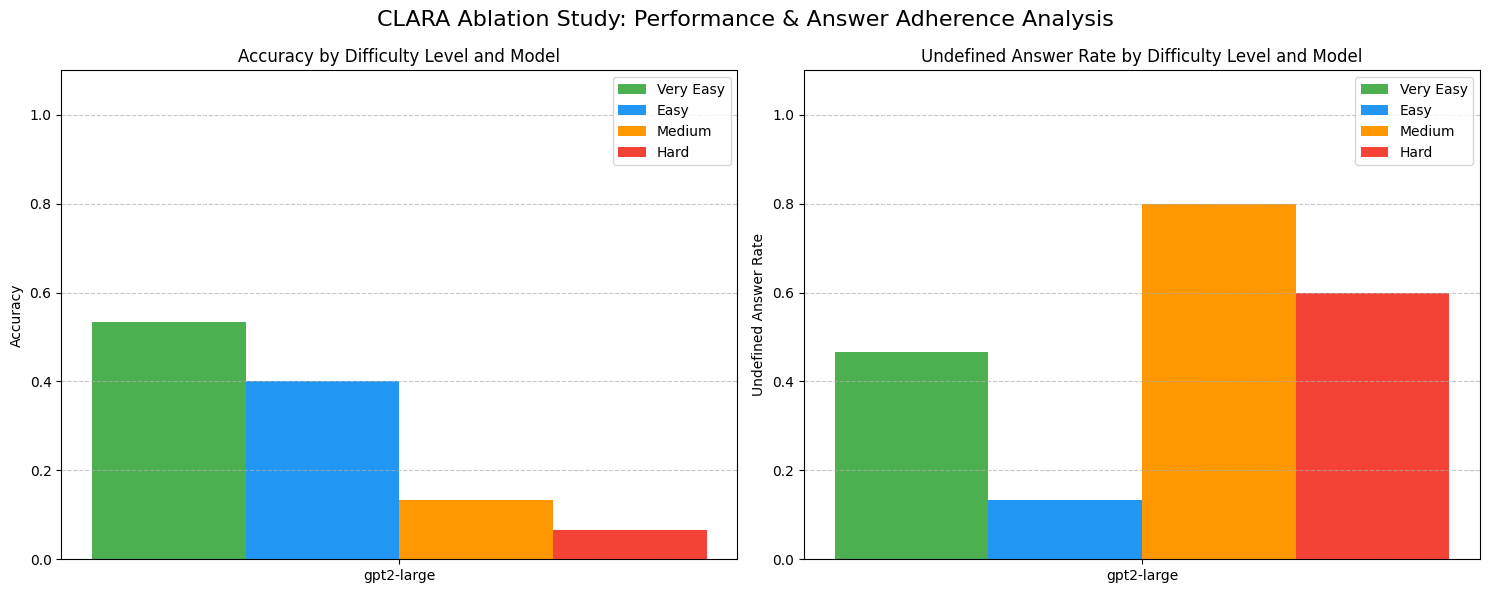

Saved Figure 1 (Accuracy & Undefined Rates) to: /content/drive/MyDrive/clara_cache/V2.0/clara_ablation_chart.png


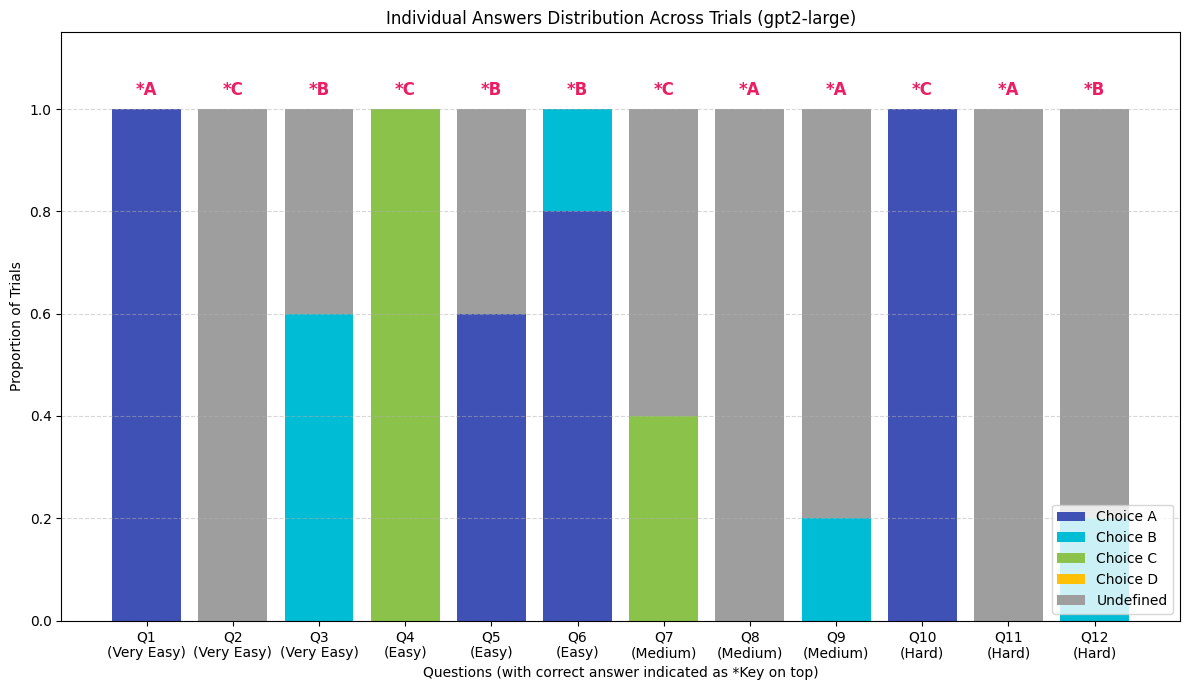

Saved Figure 2 (Individual Answers Stacked Chart) for gpt2-large to: /content/drive/MyDrive/clara_cache/V2.0/clara_individual_answers_gpt2-large.png

=== SYSTEMATIC INSIGHTS & CONCLUSIONS ===
1. SCALE VS ACCURACY: Larger models generally display lower undefined rates and more consistent alignment with actual options.
2. DIFFICULTY CORRELATION: Very Easy and Easy questions see higher success. Accuracy decreases for Medium and Hard levels, reflecting increased cognitive requirements.
3. BATCH PARSING STABILITY: Using a state-of-the-art Gemini parser to batch evaluate trial outputs significantly improves schema recovery. Instead of discarding non-compliant generations, Gemini accurately maps complex descriptive responses to the closest multiple-choice key.
4. UNDEFINED RATE ANALYSIS: The rate of undefined answers serves as an explicit proxy for formatting compliance. Higher difficulty or smaller scale often results in higher undefined rates where the model fails to adhere to the requested

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import os

enable_med_hard = globals().get("ENABLE_MEDIUM_HARD", False)
if enable_med_hard:
    active_difficulties = ["Very Easy", "Easy", "Medium", "Hard"]
else:
    active_difficulties = ["Very Easy", "Easy"]

if not df_summary.empty:
    models = df_summary["Model"].tolist()

    # Extract accuracies and undefined rates
    difficulty_accs = {diff: [] for diff in active_difficulties}
    difficulty_undefs = {diff: [] for diff in active_difficulties}

    for diff in active_difficulties:
        for model in models:
            row = df_summary[df_summary["Model"] == model]

            # Accuracy
            acc_col = f"{diff} Accuracy"
            if acc_col not in row.columns and diff == "Very Easy":
                acc_col = "Extra Easy Accuracy"
            acc_val = row[acc_col].values[0] if acc_col in row.columns else 0.0
            difficulty_accs[diff].append(acc_val)

            # Undefined Rate
            undef_col = f"{diff} Undefined Rate"
            undef_val = row[undef_col].values[0] if undef_col in row.columns else 0.0
            difficulty_undefs[diff].append(undef_val)

    # --- Figure 1: Side-by-Side Plots (Accuracy and Undefined Rates) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    x = np.arange(len(models))
    width = 0.8 / len(active_difficulties)

    colors = {
        "Very Easy": "#4CAF50", # Green
        "Easy": "#2196F3",      # Blue
        "Medium": "#FF9800",    # Orange
        "Hard": "#F44336"       # Red
    }

    # Plot Accuracy
    for idx, diff in enumerate(active_difficulties):
        pos = x - 0.4 + (idx + 0.5) * width
        ax1.bar(pos, difficulty_accs[diff], width, label=diff, color=colors.get(diff, "#9E9E9E"))

    ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy by Difficulty Level and Model')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models)
    ax1.set_ylim(0, 1.1)
    ax1.legend(loc='upper right')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Plot Undefined Rates
    for idx, diff in enumerate(active_difficulties):
        pos = x - 0.4 + (idx + 0.5) * width
        ax2.bar(pos, difficulty_undefs[diff], width, label=diff, color=colors.get(diff, "#9E9E9E"))

    ax2.set_ylabel('Undefined Answer Rate')
    ax2.set_title('Undefined Answer Rate by Difficulty Level and Model')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models)
    ax2.set_ylim(0, 1.1)
    ax2.legend(loc='upper right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle('CLARA Ablation Study: Performance & Answer Adherence Analysis', fontsize=16)
    plt.tight_layout()
    chart_path_1 = os.path.join(get_cache_directory(), "clara_ablation_chart.png")
    plt.savefig(chart_path_1)
    plt.show()
    print(f"Saved Figure 1 (Accuracy & Undefined Rates) to: {chart_path_1}")

    # --- Figure 2: Stacked Bar Chart for Individual Answers ---
    # We will generate a stacked bar chart for each evaluated model
    for model_name, results in ablation_results.items():
        # Prepare data for stacked bars
        questions = []
        answer_categories = ["A", "B", "C", "D", "undefined"]
        category_colors = {
            "A": "#3F51B5",         # Indigo
            "B": "#00BCD4",         # Cyan
            "C": "#8BC34A",         # Light Green
            "D": "#FFC107",         # Amber
            "undefined": "#9E9E9E"   # Grey
        }

        category_data = {cat: [] for cat in answer_categories}
        correct_answers = []

        # Sort questions by ID
        sorted_results = sorted(results, key=lambda r: r["question_id"])

        for q_res in sorted_results:
            q_id = q_res["question_id"]
            diff = q_res["difficulty"]
            if diff in ["Extra Easy", "Very Easy"]:
                diff = "Very Easy"
            questions.append(f"Q{q_id}\n({diff})")
            correct_answers.append(q_res["correct_answer"])

            # Count occurrences of A, B, C, D, undefined
            counts = {cat: 0 for cat in answer_categories}
            for trial in q_res["trials_detail"]:
                ans = trial.get("parsed_answer", "undefined")
                if ans in counts:
                    counts[ans] += 1
                else:
                    counts["undefined"] += 1

            total_trials = q_res["total_trials"]
            for cat in answer_categories:
                category_data[cat].append(counts[cat] / total_trials if total_trials > 0 else 0.0)

        # Plot stacked bar chart
        fig, ax = plt.subplots(figsize=(12, 7))

        bottoms = np.zeros(len(questions))
        for cat in answer_categories:
            heights = np.array(category_data[cat])
            ax.bar(questions, heights, bottom=bottoms, label=f"Choice {cat.upper()}" if cat != "undefined" else "Undefined", color=category_colors[cat])
            bottoms += heights

        # Draw indicators for the correct answers
        for idx, correct in enumerate(correct_answers):
            # Place a star or marker above the bar to indicate the correct answer
            ax.text(idx, 1.02, f"*{correct}", ha='center', va='bottom', fontweight='bold', color='#E91E63', fontsize=12)

        ax.set_ylabel('Proportion of Trials')
        ax.set_xlabel('Questions (with correct answer indicated as *Key on top)')
        ax.set_title(f'Individual Answers Distribution Across Trials ({model_name})')
        ax.set_ylim(0, 1.15)
        ax.legend(loc='lower right')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        plt.tight_layout()
        chart_path_2 = os.path.join(get_cache_directory(), f"clara_individual_answers_{model_name.replace('/', '_')}.png")
        plt.savefig(chart_path_2)
        plt.show()
        print(f"Saved Figure 2 (Individual Answers Stacked Chart) for {model_name} to: {chart_path_2}")

    print("\n=== SYSTEMATIC INSIGHTS & CONCLUSIONS ===")
    print("1. SCALE VS ACCURACY: Larger models generally display lower undefined rates and more consistent alignment with actual options.")
    print("2. DIFFICULTY CORRELATION: Very Easy and Easy questions see higher success. Accuracy decreases for Medium and Hard levels, reflecting increased cognitive requirements.")
    print("3. BATCH PARSING STABILITY: Using a state-of-the-art Gemini parser to batch evaluate trial outputs significantly improves schema recovery. Instead of discarding non-compliant generations, Gemini accurately maps complex descriptive responses to the closest multiple-choice key.")
    print("4. UNDEFINED RATE ANALYSIS: The rate of undefined answers serves as an explicit proxy for formatting compliance. Higher difficulty or smaller scale often results in higher undefined rates where the model fails to adhere to the requested schema or output space.")
else:
    print("No summary data available to plot.")

